In [1]:
import os

# Only mount Drive on real Google Colab (env var is set there). If `google-colab` is
# installed locally, `drive.mount()` can hang forever — so we never mount unless on Colab.
if os.environ.get("COLAB_RELEASE_TAG"):
    from google.colab import drive
    drive.mount("/content/drive")
else:
    print("Local run — skipping Google Drive mount.")



Local run — skipping Google Drive mount.


In [2]:
import pandas as pd

In [3]:
import os

# Prefer outputs from notebook 01 (same folder as this notebook)
for file_path in (
    "sports_random_50k_final.csv",
    "sports_balanced_50k.csv",
    "6165 group/sports_balanced_50k.csv",
):
    if os.path.isfile(file_path):
        break
else:
    raise FileNotFoundError(
        "No dataset CSV found. Place sports_random_50k_final.csv or sports_balanced_50k.csv "
        "in this folder (from 01_Data_Retrieval_and_Merging.ipynb)."
    )

print(f"Loading: {file_path}")
df = pd.read_csv(file_path)
print("Successfully loaded the dataset!")

print(df.head())
print(df.info())
print(df.describe())


Loading: sports_random_50k_final.csv
Successfully loaded the dataset!
   rating                                        title  \
0     1.0  Too wide of opening angle, lengthy assembly   
1     5.0                            Grandson approved   
2     3.0             But from reviews should be good.   
3     5.0                                   Five Stars   
4     4.0             it is good fot what i use it for   

                                                text images        asin  \
0  Doesn't hold snug any of the 2 kayaks I have, ...     []  B071WYKQW9   
1  I have two grandsons that are baseball fanatic...     []  B00D3PNZB0   
2  Haven't tried yet. But from reviews should be ...     []  B007W5T8TK   
3                       Price is good handle id good     []  B017XA9IKW   
4  it is good fot what i use it for, reason for 4...     []  B000EPMK8Q   

  parent_asin                       user_id      timestamp  helpful_vote  \
0  B071WYKQW9  AEKIRFCYGNHDUPLAWKLZ65E63HJQ  156666428

# Step 2: Cleaning & Missing Values

In [4]:
# Convert timestamp from milliseconds to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')

print("Missing values:\n", df.isnull().sum())

df['text'] = df['text'].fillna('')
df['title'] = df['title'].fillna('')

# Vectorized (avoid .apply per row)
df['text_length'] = df['text'].astype(str).str.len()


Missing values:
 rating               0
title                3
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
product_name         0
sentiment            0
word_count           0
dtype: int64


# Step 3: Target Variable Distribution (Sentiment & Rating)

/var/folders/rw/gqkkbg9x3l17qbh16qw3pw4m0000gn/T/ipykernel_11220/902574412.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', palette='viridis', ax=ax[0])
/var/folders/rw/gqkkbg9x3l17qbh16qw3pw4m0000gn/T/ipykernel_11220/902574412.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='magma', ax=ax[1])


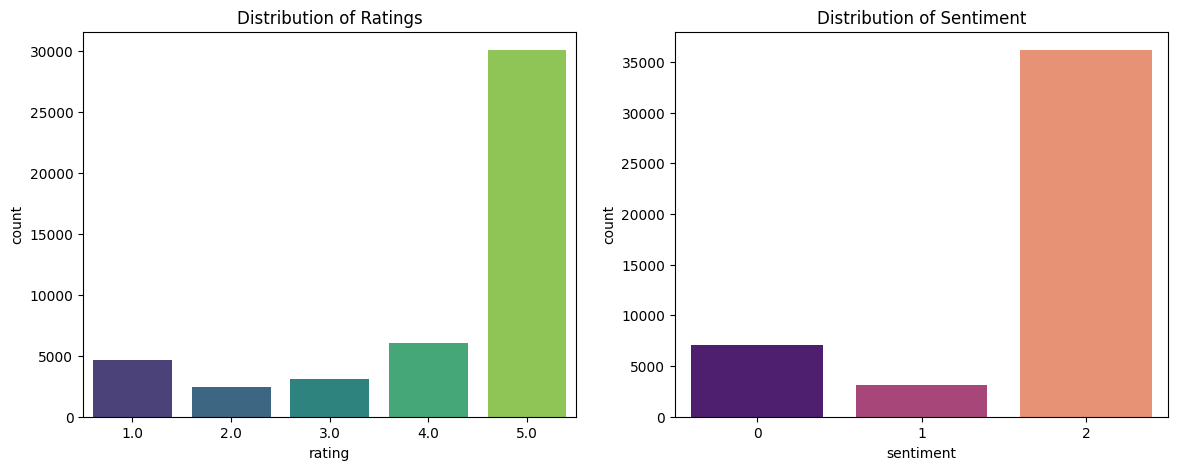

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Ratings distribution
sns.countplot(data=df, x='rating', palette='viridis', ax=ax[0])
ax[0].set_title('Distribution of Ratings')

# Plot 2: Sentiment distribution
sns.countplot(data=df, x='sentiment', palette='magma', ax=ax[1])
ax[1].set_title('Distribution of Sentiment')

plt.show()

# Step 4: Relationship Analysis (Helpfulness & Length)

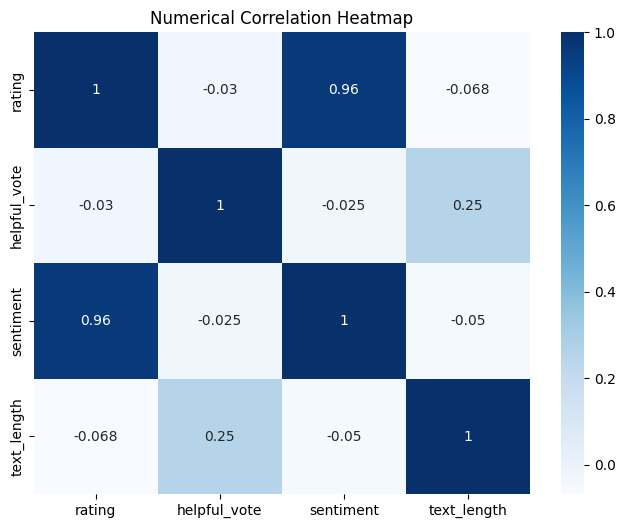

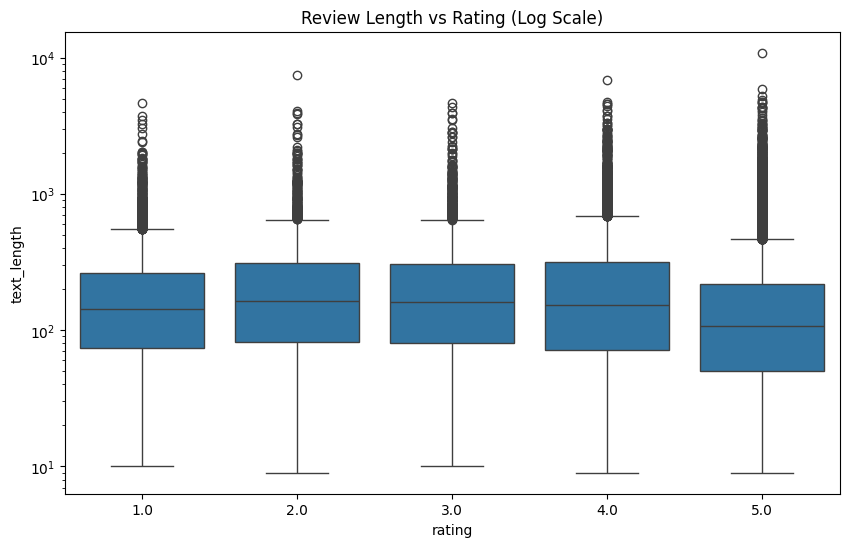

In [6]:
# 1. Correlation between numerical features
plt.figure(figsize=(8, 6))
sns.heatmap(df[['rating', 'helpful_vote', 'sentiment', 'text_length']].corr(),
            annot=True, cmap='Blues')
plt.title('Numerical Correlation Heatmap')
plt.show()

# 2. Does text length vary by rating?
plt.figure(figsize=(10, 6))
sns.boxplot(x='rating', y='text_length', data=df)
plt.yscale('log') # Using log scale because some reviews are very long
plt.title('Review Length vs Rating (Log Scale)')
plt.show()

# Step 5: Time-Series Analysis

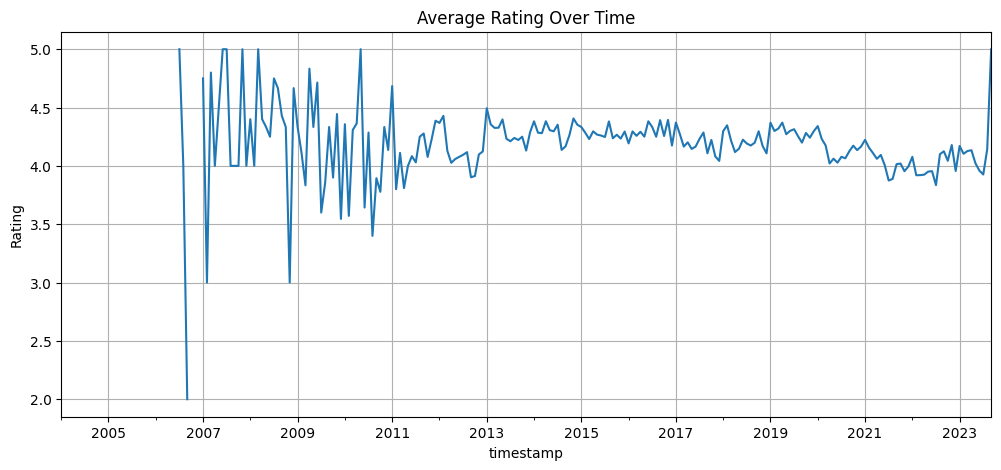

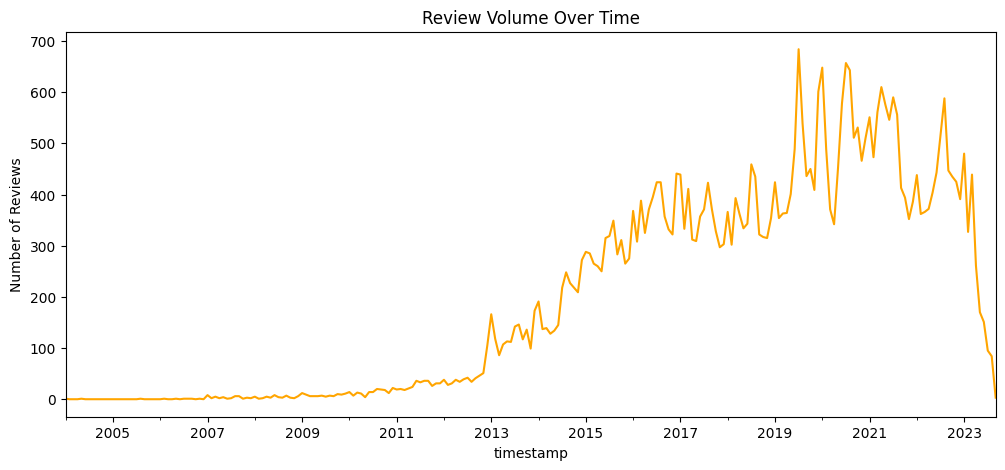

In [7]:
import matplotlib.pyplot as plt

# Single set_index; avoid repeating work
df_ts = df.set_index('timestamp')

df_ts.resample('ME')['rating'].mean().plot(figsize=(12, 5))
plt.title('Average Rating Over Time')
plt.ylabel('Rating')
plt.grid(True)
plt.show()

df_ts.resample('ME').size().plot(figsize=(12, 5), color='orange')
plt.title('Review Volume Over Time')
plt.ylabel('Number of Reviews')
plt.show()


In [8]:
# Word count without Python apply (much faster)
df['word_count'] = df['text'].astype(str).str.split().str.len()

print("📊 Text Length Statistics (Word Count) by Sentiment:")
quality_stats = df.groupby('sentiment')['word_count'].describe()[['count', 'mean', 'std', 'min', 'max']]
print(quality_stats)

short_reviews_count = (df['word_count'] < 3).sum()
print(f"\n⚠️ Number of very short reviews (< 3 words): {short_reviews_count}")


📊 Text Length Statistics (Word Count) by Sentiment:
             count       mean        std  min     max
sentiment                                            
0           7076.0  43.998587  55.922698  3.0  1356.0
1           3135.0  49.356619  63.063640  3.0   864.0
2          36182.0  37.721491  54.719253  3.0  2038.0

⚠️ Number of very short reviews (< 3 words): 0


# Step 6: Advanced EDA Optimizations

These snippets address the "hidden" patterns: the density of review lengths and the influence of "Verified Purchases

In [11]:
%pip install wordcloud


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


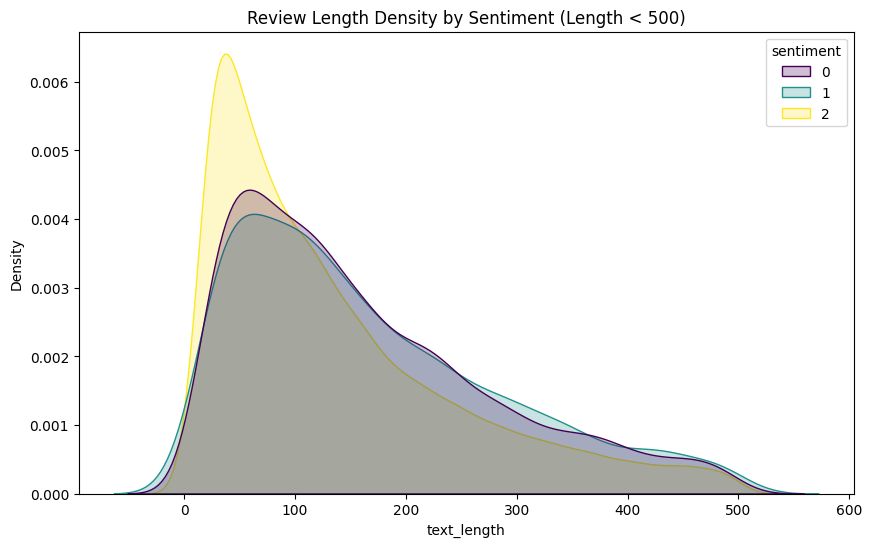

/var/folders/rw/gqkkbg9x3l17qbh16qw3pw4m0000gn/T/ipykernel_11220/2109926288.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='verified_purchase', y='rating', data=df, palette='magma')


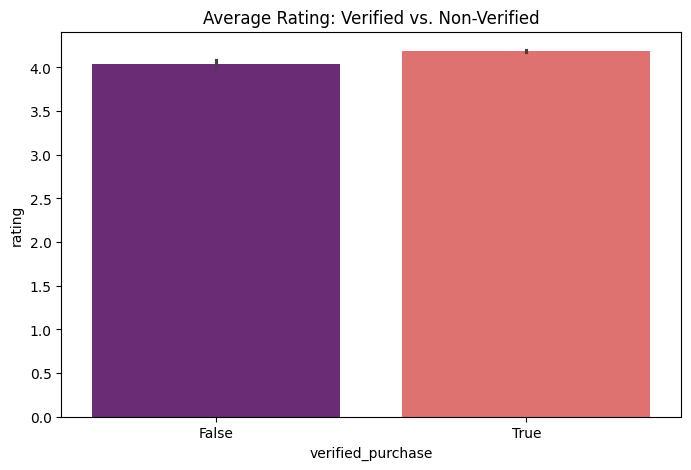

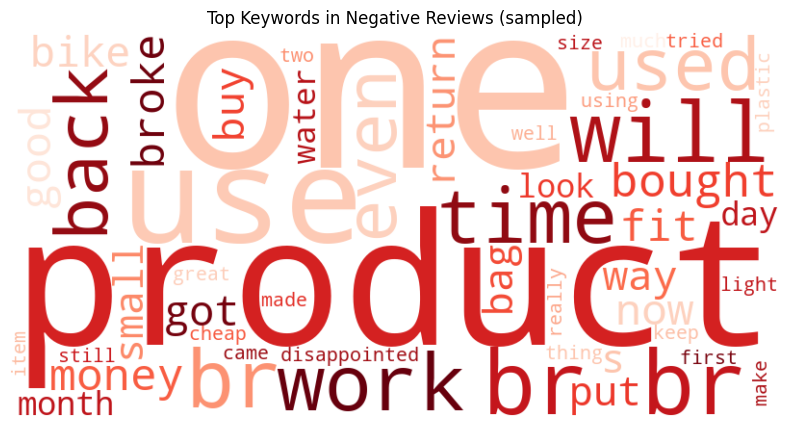

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Density plot (subset keeps KDE fast)
sub = df[df['text_length'] < 500]
plt.figure(figsize=(10, 6))
sns.kdeplot(data=sub, x='text_length', hue='sentiment',
            common_norm=False, palette='viridis', fill=True)
plt.title('Review Length Density by Sentiment (Length < 500)')
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x='verified_purchase', y='rating', data=df, palette='magma')
plt.title('Average Rating: Verified vs. Non-Verified')
plt.show()

# WordCloud: subsample negative reviews so generation stays fast
neg = df.loc[df['sentiment'] == 0, 'text']
if len(neg) > 8000:
    neg = neg.sample(8000, random_state=42)
neg_text = " ".join(neg.astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white',
                      max_words=50, colormap='Reds').generate(neg_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top Keywords in Negative Reviews (sampled)')
plt.show()


# Step 7: Data Cleaning

In [13]:
import numpy as np

# Vectorized HTML removal (avoid per-row Python apply)
df['text'] = df['text'].astype(str).str.replace(r'<[^>]+>', '', regex=True)
df['title'] = df['title'].astype(str).str.replace(r'<[^>]+>', '', regex=True)

df['text'] = df['text'].fillna('no_text')
df['title'] = df['title'].fillna('no_title')

df['text'] = df['text'].str.lower().str.strip()

df['helpful_log'] = np.log1p(df['helpful_vote'])

initial_shape = df.shape[0]
df = df.drop_duplicates(subset=['user_id', 'timestamp', 'text'])
print(f"Removed {initial_shape - df.shape[0]} duplicate reviews.")

print("Cleaning Complete!")


Removed 0 duplicate reviews.
Cleaning Complete!


# Step8:Text Preprocessing

In [15]:
%pip install nltk
import nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [nltk]2/3 [nltk]]

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [16]:
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
import re

def _ensure_nltk():
    try:
        nltk.data.find('corpora/stopwords')
    except LookupError:
        nltk.download('stopwords', quiet=True)

_ensure_nltk()

stop_words = set(stopwords.words('english'))
stemmer = SnowballStemmer("english")
# Alphabetic tokens with length >= 3 (same idea as your filters)
_TOKEN = re.compile(r"[A-Za-z]{3,}")

def preprocess_text(text: str) -> str:
    if not isinstance(text, str) or not text:
        return ""
    words = _TOKEN.findall(text.lower())
    out = []
    for w in words:
        if w in stop_words:
            continue
        out.append(stemmer.stem(w))
    return " ".join(out)

# Regex tokenization is much faster than nltk.word_tokenize; tqdm shows progress on long runs
try:
    from tqdm.auto import tqdm
    tqdm.pandas()
    df['clean_text_final'] = df['text'].progress_apply(preprocess_text)
except Exception:
    df['clean_text_final'] = df['text'].map(preprocess_text)

print("Preprocessing Complete!")
print(df[['text', 'clean_text_final']].head())


/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 46393/46393 [00:07<00:00, 5881.43it/s]

Preprocessing Complete!
                                                text  \
0  doesn't hold snug any of the 2 kayaks i have, ...   
1  i have two grandsons that are baseball fanatic...   
2  haven't tried yet. but from reviews should be ...   
3                       price is good handle id good   
4  it is good fot what i use it for, reason for 4...   

                                    clean_text_final  
0  hold snug kayak way wide open angl top assembl...  
1  two grandson basebal fanat hit bucket time wee...  
2                                tri yet review good  
3                              price good handl good  
4  good fot use reason materi feel stiff qualiti ...  


# Step 9: Post-Preprocessing Analysis

/var/folders/rw/gqkkbg9x3l17qbh16qw3pw4m0000gn/T/ipykernel_11220/3186243327.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=word_df, x='count', y='word', palette='viridis')


Top 20 Stemmed Words:
 [('use', 14039), ('great', 12224), ('work', 8752), ('one', 8368), ('like', 7754), ('good', 7697), ('love', 7356), ('get', 6538), ('well', 6483), ('would', 6006), ('product', 5964), ('fit', 5920), ('easi', 5669), ('time', 5095), ('look', 4814), ('qualiti', 4458), ('perfect', 4336), ('nice', 4244), ('need', 4076), ('realli', 3967)]


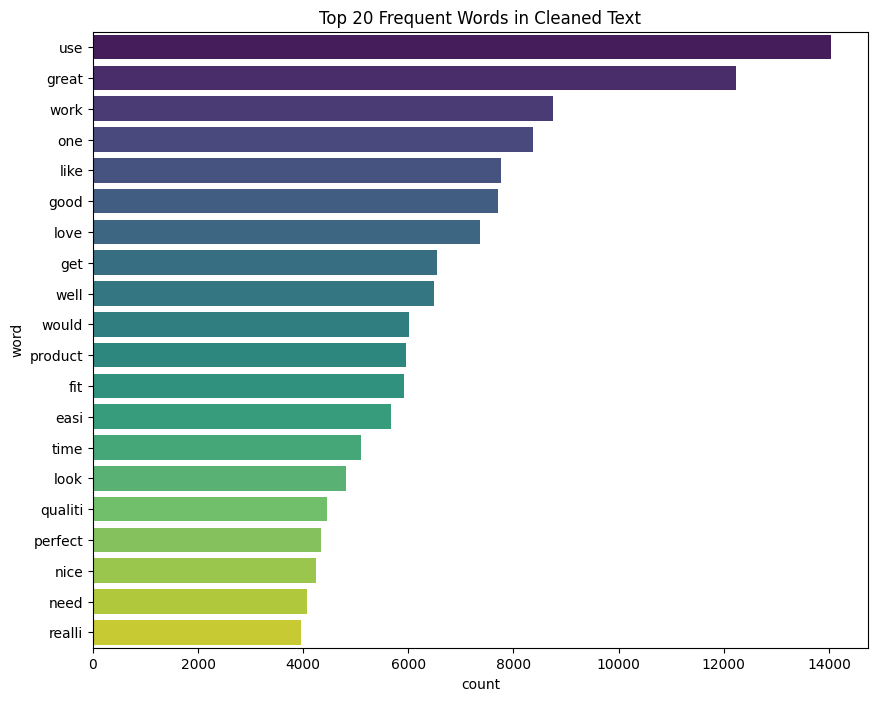

In [17]:
from collections import Counter

# Combine all cleaned text into one large list of words
all_words = " ".join(df['clean_text_final']).split()
word_freq = Counter(all_words)

# Look at Top 20 words
common_words = word_freq.most_common(20)
print("Top 20 Stemmed Words:\n", common_words)

# Plot the frequencies
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

word_df = pd.DataFrame(common_words, columns=['word', 'count'])
plt.figure(figsize=(10, 8))
sns.barplot(data=word_df, x='count', y='word', palette='viridis')
plt.title('Top 20 Frequent Words in Cleaned Text')
plt.show()

/var/folders/rw/gqkkbg9x3l17qbh16qw3pw4m0000gn/T/ipykernel_11220/704219800.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, palette='rocket')


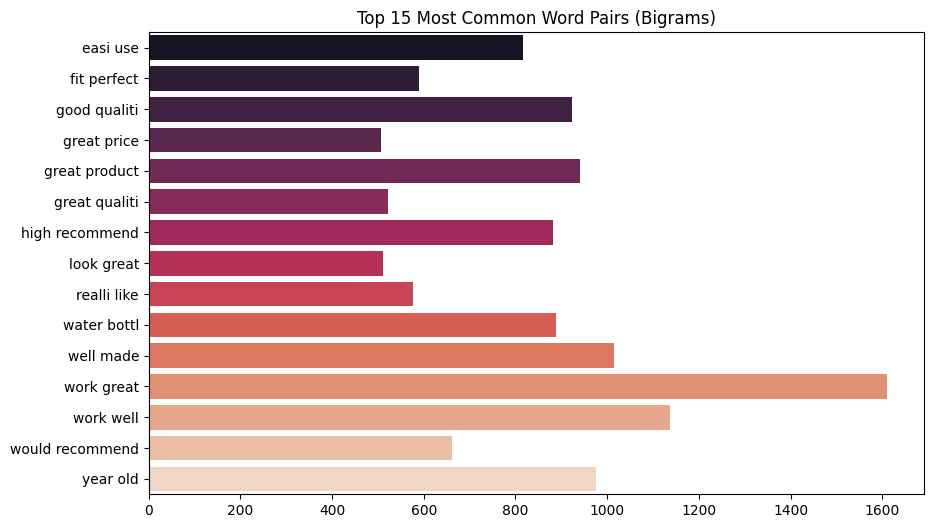

In [18]:
from sklearn.feature_extraction.text import CountVectorizer

# Get the most frequent 2-word combinations
cv = CountVectorizer(ngram_range=(2, 2), max_features=15)
bigrams = cv.fit_transform(df['clean_text_final'])
counts = bigrams.sum(axis=0).A1
words = cv.get_feature_names_out()

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(x=counts, y=words, palette='rocket')
plt.title('Top 15 Most Common Word Pairs (Bigrams)')
plt.show()

In [19]:
# 1. Top 10 most reviewed products (ASINs)
top_asins = df['parent_asin'].value_counts().head(10)
print("Most reviewed products:\n", top_asins)

# 2. Check the text for the most popular product
top_product_id = top_asins.index[0]
sample_reviews = df[df['parent_asin'] == top_product_id]['text'].head(3)
print(f"\nSample reviews for top product ({top_product_id}):\n", sample_reviews.values)

Most reviewed products:
 parent_asin
B00NWXLQD2    87
B07BQRWTDJ    59
B0C5RBPW2Y    47
B0BBFB48YQ    46
B09MJKJYLQ    43
B01L6RE7Z4    42
B0B7J8Y581    38
B0C5XW2T2N    36
B00BGO0Q9O    35
B01M0D52OK    35
Name: count, dtype: int64

Sample reviews for top product (B00NWXLQD2):
 <StringArray>
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [20]:
# A simple keyword scan to examine the data composition.
categories = {
    'Footwear/Socks': ['sock', 'boot', 'shoe', 'wear', 'feet'],
    'Equestrian/Horse': ['saddle', 'horse', 'halter', 'bridle', 'riding'],
    'Hydration': ['bottle', 'water', 'leak', 'drink', 'cup'],
    'Apparel': ['shirt', 'size', 'fit', 'wash', 'fabric']
}

for cat, keywords in categories.items():
    count = df['clean_text_final'].str.contains('|'.join(keywords)).sum()
    print(f"{cat}: {count} reviews")

Footwear/Socks: 2350 reviews
Equestrian/Horse: 24 reviews
Hydration: 3601 reviews
Apparel: 8365 reviews


In [21]:
# Save the processed 50,000 data entries as a CSV file
# index=False is used to prevent pandas from automatically adding an extra ID column
df.to_csv('cleaned_amazon_reviews.csv', index=False)

print("Data has been successfully exported to the local disk:cleaned_amazon_reviews.csv")

Data has been successfully exported to the local disk:cleaned_amazon_reviews.csv
